In [ ]:
%cd /content

!git clone https://github.com/Aishwarya-93/Deepfake-Detection-KYC.git

%cd Deepfake-Detection-KYC

/content
Cloning into 'Deepfake-Detection-KYC'...
remote: Enumerating objects: 237, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 237 (delta 0), reused 2 (delta 0), pack-reused 232 (from 1)
Receiving objects: 100% (237/237), 6.44 MiB | 24.50 MiB/s, done.
Resolving deltas: 100% (118/118), done.
/content/Deepfake-Detection-KYC


In [ ]:
!pip uninstall -y opencv-python opencv-contrib-python opencv-python-headless
!pip install opencv-python==4.10.0.84

Found existing installation: opencv-python 5.0.0.93
Uninstalling opencv-python-5.0.0.93:
  Successfully uninstalled opencv-python-5.0.0.93
Found existing installation: opencv-contrib-python 4.13.0.92
Uninstalling opencv-contrib-python-4.13.0.92:
  Successfully uninstalled opencv-contrib-python-4.13.0.92
Found existing installation: opencv-python-headless 5.0.0.93
Uninstalling opencv-python-headless-5.0.0.93:
  Successfully uninstalled opencv-python-headless-5.0.0.93
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 14.2 MB/s eta 0:00:00


In [ ]:
import cv2

print(cv2.__version__)
print(hasattr(cv2, "CascadeClassifier"))

4.10.0
True


In [ ]:
import sys
# Explicitly add the absolute path of the project root to ensure modules are found.
sys.path.insert(0, '/content/Deepfake-Detection-KYC')

from pathlib import Path

import torch
from torch.utils.data import DataLoader
from torchvision import transforms

import matplotlib.pyplot as plt

# Revert to the correct import path based on the repository structure
from src.dataset.dataloader import FaceDataset

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
print("PyTorch version:", torch.__version__)

if torch.cuda.is_available():
    print("CUDA available: Yes")
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("CUDA available: No")

PyTorch version: 2.11.0+cpu
CUDA available: No


In [ ]:
!pip install -q kaggle

In [ ]:
import os
from getpass import getpass

os.environ["KAGGLE_USERNAME"] = input("Kaggle username: ")
os.environ["KAGGLE_API_TOKEN"] = getpass("Kaggle API token: ")

Kaggle username: tanvi2609
Kaggle API token: ··········


In [ ]:
!mkdir -p /content/processed_dataset

!kaggle datasets download \
    -d aishwarya99990/faceforensics-kyc-processed \
    -p /content/processed_dataset \
    --unzip

Dataset URL: https://www.kaggle.com/datasets/aishwarya99990/faceforensics-kyc-processed
License(s): CC0-1.0
100% 11.1M/11.1M [00:00<00:00, 114MB/s]



In [ ]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

DATASET_ROOT = Path("/content/processed_dataset")

# Find one processed face
sample_images = list(DATASET_ROOT.rglob("*.jpg"))

print("Number of processed images:", len(sample_images))
print("Sample:", sample_images[0])

Number of processed images: 1044
Sample: /content/processed_dataset/train/real/818_frame0_face0.jpg


Image mode: RGB
Image size: (224, 224)


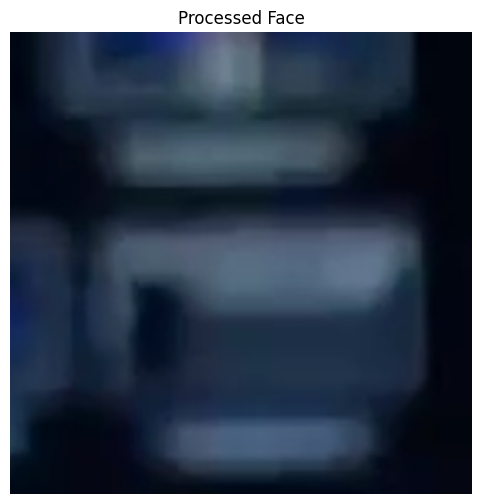

In [ ]:
img = Image.open(sample_images[0])

print("Image mode:", img.mode)
print("Image size:", img.size)

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title("Processed Face")
plt.show()

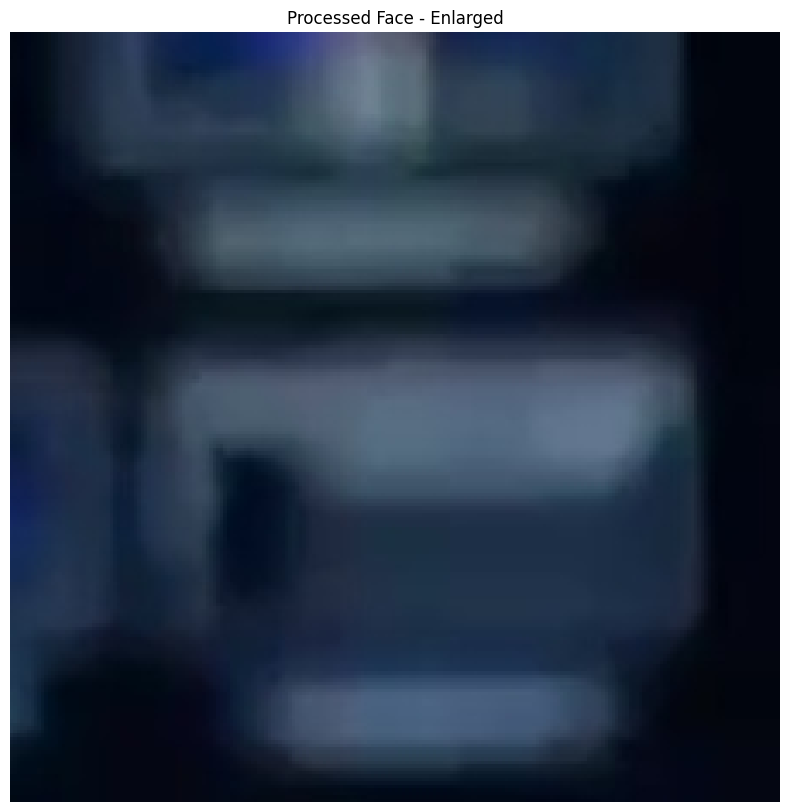

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis("off")
plt.title("Processed Face - Enlarged")
plt.show()

In [ ]:
print("Size:", img.size)
print("Mode:", img.mode)

Size: (224, 224)
Mode: RGB


Total processed images: 1044
Sample file:
/content/processed_dataset/train/real/818_frame0_face0.jpg
Image mode: RGB
Image size: (224, 224)


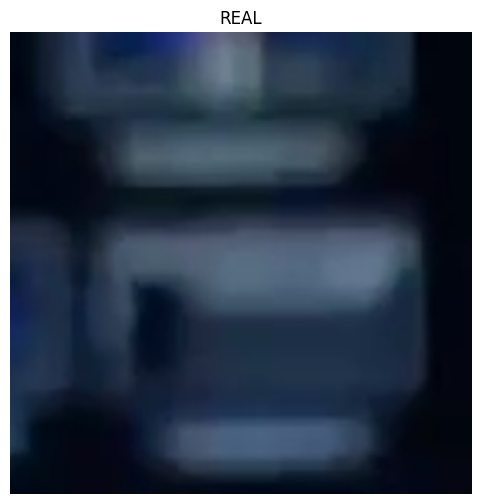

In [ ]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

DATASET_ROOT = Path("/content/processed_dataset")

images = list(DATASET_ROOT.rglob("*.jpg"))

print("Total processed images:", len(images))

if len(images) == 0:
    raise RuntimeError("No JPG images found.")

sample = images[0]

print("Sample file:")
print(sample)

img = Image.open(sample)

print("Image mode:", img.mode)
print("Image size:", img.size)

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title(f"{sample.parent.name.upper()}")
plt.show()

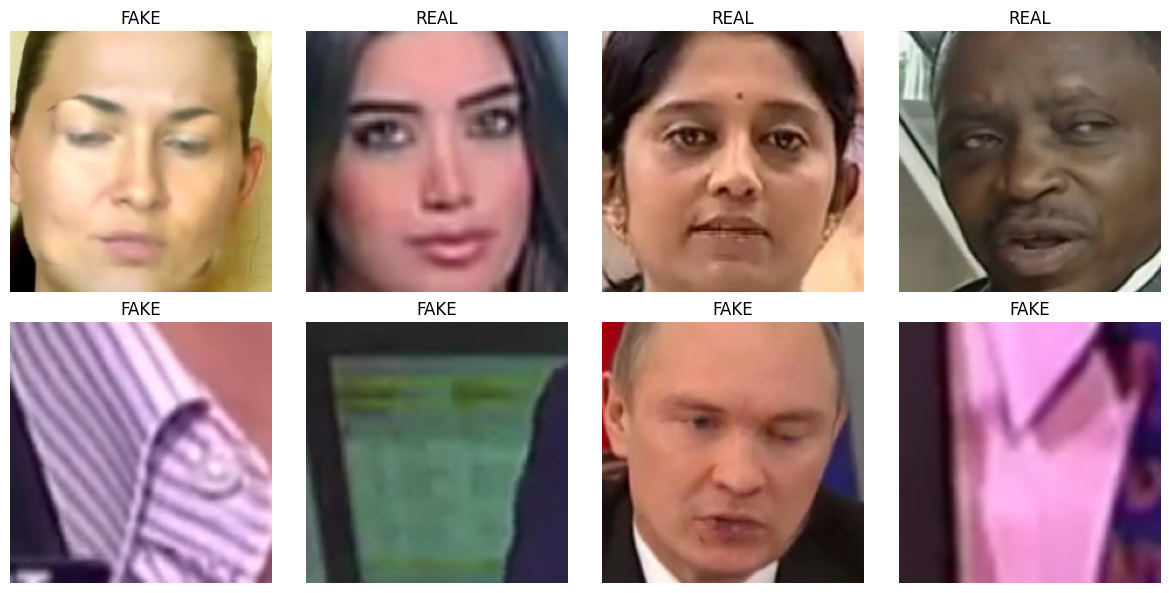

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image

samples = random.sample(images, min(8, len(images)))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax, path in zip(axes.flat, samples):

    img = Image.open(path)

    ax.imshow(img)
    ax.set_title(path.parent.name.upper())
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from pathlib import Path

import torch
import torchvision
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms

from src.dataset.dataloader import FaceDataset

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)

PyTorch: 2.11.0+cpu
Torchvision: 0.26.0+cpu


In [ ]:
DATASET_ROOT = Path("/content/processed_dataset")

TRAIN_DIR = DATASET_ROOT / "train"
VAL_DIR = DATASET_ROOT / "val"
TEST_DIR = DATASET_ROOT / "test"

print("Train:", TRAIN_DIR)
print("Validation:", VAL_DIR)
print("Test:", TEST_DIR)

Train: /content/processed_dataset/train
Validation: /content/processed_dataset/val
Test: /content/processed_dataset/test


In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
images, labels = next(iter(train_loader))

print("Images:", images.shape)
print("Labels:", labels.shape)
print("Labels:", labels)

Images: torch.Size([16, 3, 224, 224])
Labels: torch.Size([16])
Labels: tensor([0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1])


In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cpu


In [ ]:
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

weights = MobileNet_V2_Weights.DEFAULT

model = mobilenet_v2(weights=weights)

num_features = model.classifier[1].in_features

model.classifier[1] = nn.Linear(
    num_features,
    2
)

model = model.to(device)

print(model.classifier)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 110MB/s] 

Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)


In [ ]:
images, labels = next(iter(train_loader))

images = images.to(device)

with torch.no_grad():
    outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)

Input shape: torch.Size([16, 3, 224, 224])
Output shape: torch.Size([16, 2])


In [ ]:
from src.dataset.dataloader import FaceDataset
from torch.utils.data import DataLoader

train_dataset = FaceDataset(
    TRAIN_DIR,
    transform=train_transform
)

val_dataset = FaceDataset(
    VAL_DIR,
    transform=eval_transform
)

test_dataset = FaceDataset(
    TEST_DIR,
    transform=eval_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("Training:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Testing:", len(test_dataset))

Training: 736
Validation: 138
Testing: 170


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)


In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    loss = running_loss / total
    accuracy = correct / total

    return loss, accuracy

In [ ]:
def evaluate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    loss = running_loss / total
    accuracy = correct / total

    return loss, accuracy

In [ ]:
EPOCHS = 5

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_val_accuracy = 0.0

MODEL_DIR = Path(
    "/content/Deepfake-Detection-KYC/outputs/models"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

BEST_MODEL_PATH = (
    MODEL_DIR / "mobilenetv2_baseline_best.pth"
)

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_acc)

    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc * 100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc * 100:.2f}%"
    )

    if val_acc > best_val_accuracy:

        best_val_accuracy = val_acc

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH
        )

        print("  ✓ Best model saved")

Epoch [1/5] | Train Loss: 0.6393 | Train Acc: 65.62% | Val Loss: 0.6876 | Val Acc: 57.97%
  ✓ Best model saved
Epoch [2/5] | Train Loss: 0.5179 | Train Acc: 79.21% | Val Loss: 0.7090 | Val Acc: 54.35%
Epoch [3/5] | Train Loss: 0.3905 | Train Acc: 85.05% | Val Loss: 0.7579 | Val Acc: 52.90%
Epoch [4/5] | Train Loss: 0.2932 | Train Acc: 89.13% | Val Loss: 0.8220 | Val Acc: 57.25%
Epoch [5/5] | Train Loss: 0.1941 | Train Acc: 93.34% | Val Loss: 0.8925 | Val Acc: 59.42%
  ✓ Best model saved


In [ ]:
model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device
    )
)

model = model.to(device)

print("Best MobileNetV2 checkpoint loaded.")
print("Best validation accuracy:", best_val_accuracy * 100, "%")

Best MobileNetV2 checkpoint loaded.
Best validation accuracy: 59.42028985507246 %


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import numpy as np

In [ ]:
model.eval()

all_labels = []
all_predictions = []
all_probabilities = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        all_labels.extend(
            labels.numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_probabilities.extend(
            probabilities[:, 1]
            .cpu()
            .numpy()
        )

In [ ]:
accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision = precision_score(
    all_labels,
    all_predictions,
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_predictions,
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_predictions,
    zero_division=0
)

roc_auc = roc_auc_score(
    all_labels,
    all_probabilities
)

print("===================================")
print("MOBILENETV2 BASELINE TEST RESULTS")
print("===================================")

print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")
print(f"F1 Score : {f1 * 100:.2f}%")
print(f"ROC-AUC  : {roc_auc:.4f}")

MOBILENETV2 BASELINE TEST RESULTS
Accuracy : 64.71%
Precision: 69.83%
Recall   : 76.42%
F1 Score : 72.97%
ROC-AUC  : 0.6324


In [ ]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[29 35]
 [25 81]]


In [ ]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=["REAL", "FAKE"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

        REAL       0.54      0.45      0.49        64
        FAKE       0.70      0.76      0.73       106

    accuracy                           0.65       170
   macro avg       0.62      0.61      0.61       170
weighted avg       0.64      0.65      0.64       170



MobileNetV2 Baseline Results

Test Accuracy: 65%

REAL Precision: 54%

REAL Recall: 45%

REAL F1: 49%

FAKE Precision: 70%

FAKE Recall: 76%

FAKE F1: 73%

Macro F1: 61%

Weighted F1: 64%

Test Samples: 170

